In [2]:
import os
import sys
import numpy as np
import cv2
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

In [3]:
# Get absolute path of the local package
local_package_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'terratorch'))

# Add the path to system path if it's not already there
if local_package_path not in sys.path:
    sys.path.insert(0, local_package_path)

# If you had previously imported terratorch, you'll need to reload it
import importlib
if 'terratorch' in sys.modules:
    importlib.reload(sys.modules['terratorch'])

import terratorch

# Verify the import
print(f"terratorch package location: {terratorch.__file__}")

/home/ejalilva/.conda/envs/prithvi/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ejalilva/.conda/envs/prithvi/lib/python3.11/site-packages/albumentations/check_version.py:51: UserWarning: Error fetching version info <urlopen error [Errno -2] Name or service not known>
  data = fetch_version_info()


terratorch package location: /gpfsm/dnb33/ejalilva/dev/terratorch/terratorch/__init__.py


In [4]:
from terratorch.datamodules import MultiTemporalCropClassificationDataModule
from terratorch.datasets import MultiTemporalCropClassification
from terratorch.tasks import SemanticSegmentationTask
from terratorch.datasets.transforms import FlattenTemporalIntoChannels, UnflattenTemporalFromChannels


In [5]:
import albumentations
from albumentations import Compose, Flip
from albumentations.pytorch import ToTensorV2

In [6]:
import lightning.pytorch as pl
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint

In [7]:
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print("Number of GPUs:", num_gpus)

Number of GPUs: 2


In [8]:
# ! tar -xvzf ../../data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-crop-classification/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/training_chips.tgz -C ../../data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-crop-classification/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/ && \
# tar -xvzf ../../data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-crop-classification/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/validation_chips.tgz -C ../../data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-crop-classification/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/ && \
# mv ../../data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-crop-classification/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/training_data.txt ../../data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-crop-classification/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/training_chips/ && \
# mv ../../data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-crop-classification/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/validation_data.txt ../../data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-crop-classification/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/validation_chips/


In [9]:
DATASET_PATH = '../../data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-crop-noncrop-classification/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/' 

In [10]:
# those are the recommended transforms for this task
transforms = [
    terratorch.datasets.transforms.FlattenTemporalIntoChannels(),
    albumentations.RandomRotate90(),
    albumentations.pytorch.transforms.ToTensorV2(),
    terratorch.datasets.transforms.UnflattenTemporalFromChannels(n_timesteps=3),
]

In [11]:
# this datamodule allows access to the dataset in its various splits.
datamodule = MultiTemporalCropClassificationDataModule(
    batch_size=16, # 16 images at a time
    data_root=DATASET_PATH,
    train_transform=transforms, # transformation to apply to the data during training
    val_transform=transforms, # transformation to apply to the data during validation
    test_transform=transforms, # transformation to apply to the data during test
    expand_temporal_dimension=True,
)

In [12]:
# checking for the dataset means and stds
datamodule.means, datamodule.stds

([494.905781, 815.239594, 924.335066, 2968.881459, 2634.621962, 1739.579917],
 [284.925432, 357.84876, 575.566823, 896.601013, 951.900334, 921.407808])

In [13]:
# checking datasets train split size
datamodule.setup("fit")
train_dataset = datamodule.train_dataset
len(train_dataset)

3083

In [14]:
# checking datasets available bands
train_dataset.all_band_names

('BLUE', 'GREEN', 'RED', 'NIR_NARROW', 'SWIR_1', 'SWIR_2')

In [15]:
# checking datasets classes
train_dataset.class_names

('Non-crop', 'Crop')

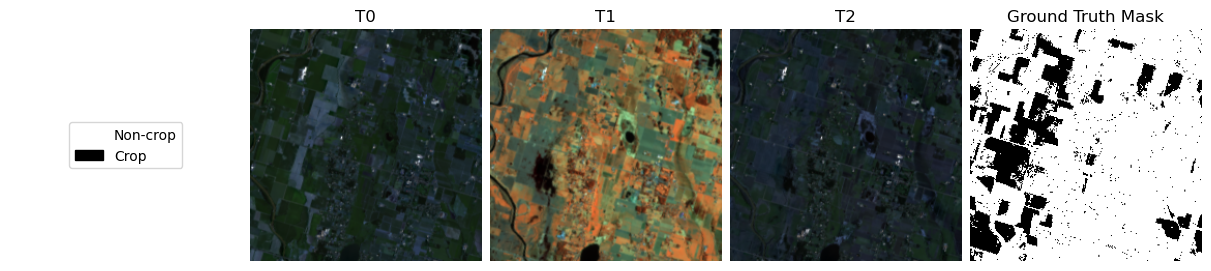

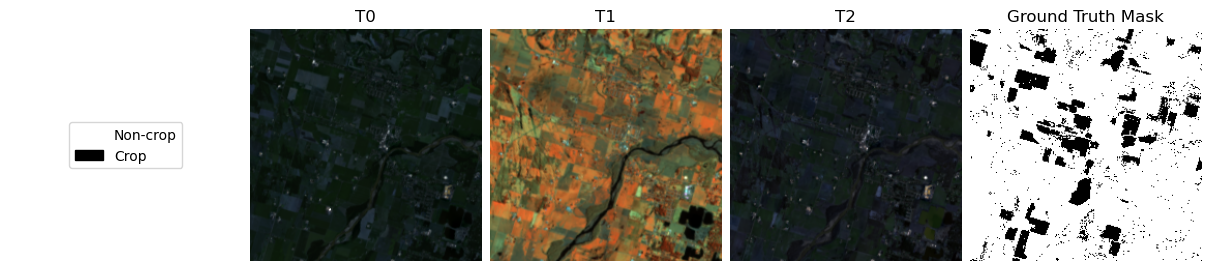

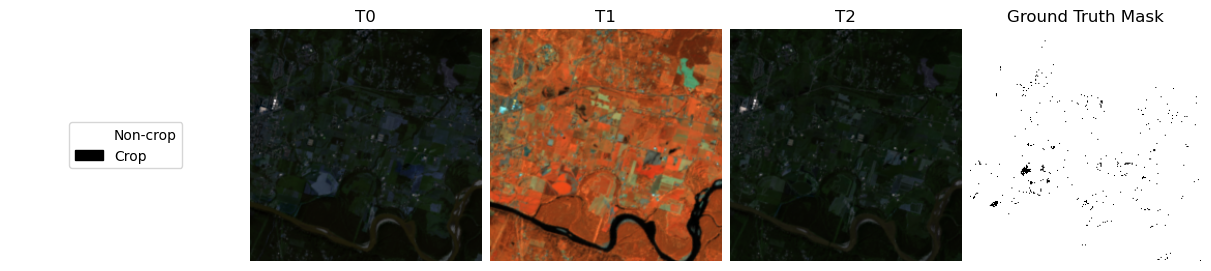

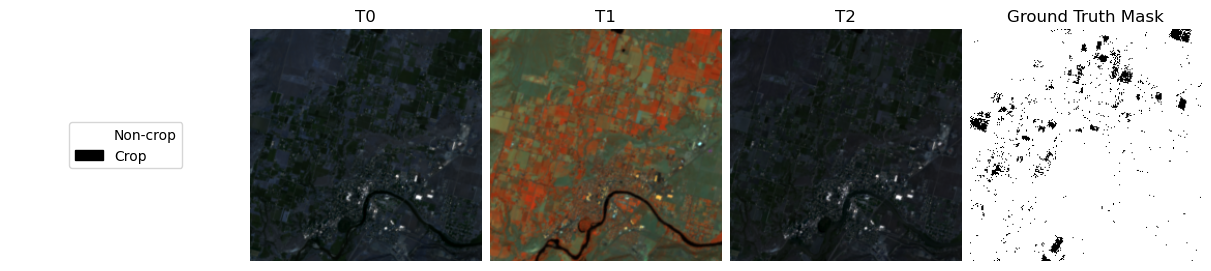

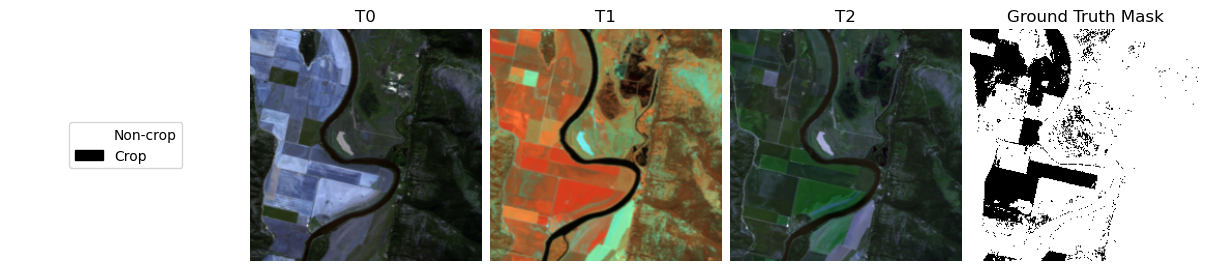

In [16]:
# ploting a few samples
for i in range(5):
    train_dataset.plot(train_dataset[i])

In [17]:
# checking datasets validation split size
val_dataset = datamodule.val_dataset
len(val_dataset)

771

In [18]:
# checking datasets testing split size
datamodule.setup("test")
test_dataset = datamodule.test_dataset
len(test_dataset)

771

In [19]:
pl.seed_everything(0)

# Logger
logger = TensorBoardLogger(
    save_dir="output",
    name="tutorial"
)

# colab will kill the kernel after ~24 epochs, therefore stopping after two and pull the correct checkpoint after
max_epochs = 1 if 'google.colab' in sys.modules else 50

checkpoint_callback = ModelCheckpoint(
    dirpath="checkpoints/",                 # Directory to save the checkpoints
    mode="max",                             # Maximize variable
    monitor="val/Multiclass_Jaccard_Index", # Variable to monitor
    filename="epoch-{epoch:02d}",           # Filename format
    save_top_k=-1,                          # Save all checkpoints
    every_n_epochs=50,                      # Save every epoch
    save_on_train_epoch_end=True            # Ensure saving after each epoch
)

# Trainer
trainer = pl.Trainer(
    accelerator="auto",
    strategy="auto",
    devices="auto",
    num_nodes=1,
    logger = logger,
    max_epochs=max_epochs,
    check_val_every_n_epoch=2,
    log_every_n_steps=10,
    enable_checkpointing=True,
    callbacks=[checkpoint_callback],
    default_root_dir="root_dir",
)

# DataModule
data_module = MultiTemporalCropClassificationDataModule(
    batch_size=8,
    data_root=DATASET_PATH,
    train_transform=transforms,
    val_transform=transforms,
    test_transform=transforms,
    reduce_zero_label=True,
    expand_temporal_dimension=True,
    use_metadata=False, # Multicropclassification dataset has metadata for location and time
)

[rank: 0] Seed set to 0
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [22]:
# Model
model = SemanticSegmentationTask(
    model_args={
        "decoder": "UperNetDecoder",
        "backbone_pretrained": True,
        "backbone": "prithvi_eo_v2_300_tl", # Model can be either prithvi_eo_v2_300, prithvi_eo_v2_300_tl, prithvi_eo_v2_600, prithvi_eo_v2_600_tl
        "backbone_in_channels": 6,
        "backbone_features_only": True,
        # "backbone_coords_encoding": ["time", "location"], # this must be used to use time and location metadata
        "rescale": True,
        "backbone_bands": ["BLUE", "GREEN", "RED", "NIR_NARROW", "SWIR_1", "SWIR_2"],
        "backbone_num_frames": 3,
        "num_classes": 2,
        "head_dropout": 0.1,
        "decoder_channels": 256,
        "decoder_scale_modules": True,
        "necks": [
            {
                "name": "SelectIndices",
                #"indices": [2, 5, 8, 11] # indices for prithvi_vit_100
                "indices": [5, 11, 17, 23] # indices for prithvi_eo_v2_300
                #"indices": [7, 15, 23, 31] # indices for prithvi_eo_v2_600
            },
            {
                "name": "ReshapeTokensToImage",
                "effective_time_dim": 3
            }
        ]

    },
    plot_on_val=False,
    class_weights=[2.47245491, 1.67913794],
    loss="ce",
    lr=2.0e-4,
    optimizer="AdamW",
    optimizer_hparams={"weight_decay": 0.1},
    ignore_index=-1,
    freeze_backbone=False,
    freeze_decoder=False,
    model_factory="EncoderDecoderFactory",
)

INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (('ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL', 'Prithvi_EO_V2_300M_TL.pt'))
INFO:root:Loaded weights for HLSBands.BLUE in position 0 of patch embed
INFO:root:Loaded weights for HLSBands.GREEN in position 1 of patch embed
INFO:root:Loaded weights for HLSBands.RED in position 2 of patch embed
INFO:root:Loaded weights for HLSBands.NIR_NARROW in position 3 of patch embed
INFO:root:Loaded weights for HLSBands.SWIR_1 in position 4 of patch embed
INFO:root:Loaded weights for HLSBands.SWIR_2 in position 5 of patch embed
/gpfsm/dnb33/ejalilva/dev/terratorch/terratorch/models/decoders/upernet_decoder.py:37: UserWarning: DeprecationWarning: scale_modules is deprecated and will be removed in future versions. Use LearnedInterpolateToPyramidal neck instead.
  warnings.warn(


In [ ]:
# Training
trainer.fit(model, datamodule=data_module)

In [23]:
trainer.test(model, datamodule=data_module, ckpt_path='checkpoints/epoch-epoch=49-v3.ckpt')

You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Restoring states from the checkpoint path at checkpoints/epoch-epoch=49-v3.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Loaded model weights from the checkpoint at checkpoints/epoch-epoch=49-v3.ckpt
SLURM auto-requeueing enabled. Setting signal handlers.
/home/ejalilva/.conda/envs/prithvi/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 97/97 [01:08<00:00,  1.42it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃             Test metric             ┃            DataLoader 0             ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test/Multiclass_Accuracy       │         0.8517137765884399          │
│      test/Multiclass_F1_Score       │         0.8517138361930847          │
│    test/Multiclass_Jaccard_Index    │          0.731411337852478          │
│ test/Multiclass_Jaccard_Index_Micro │         0.7417260408401489          │
│              test/loss              │          0.319717675447464          │
│      test/multiclassaccuracy_0      │         0.8986535668373108          │
│      test/multiclassaccuracy_1      │         0.7815718650817871          │
│    test/multiclassjaccardindex_0    │          0.784045934677124          │
│    test/multiclassjaccardindex_1    │         0.6787768006324768          │
└─────────────────────────────────────┴─────────────────────────────────────┘

[{'test/loss': 0.319717675447464,
  'test/Multiclass_Accuracy': 0.8517137765884399,
  'test/multiclassaccuracy_0': 0.8986535668373108,
  'test/multiclassaccuracy_1': 0.7815718650817871,
  'test/Multiclass_F1_Score': 0.8517138361930847,
  'test/Multiclass_Jaccard_Index': 0.731411337852478,
  'test/multiclassjaccardindex_0': 0.784045934677124,
  'test/multiclassjaccardindex_1': 0.6787768006324768,
  'test/Multiclass_Jaccard_Index_Micro': 0.7417260408401489}]

INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (('ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL', 'Prithvi_EO_V2_300M_TL.pt'))
INFO:root:Loaded weights for HLSBands.BLUE in position 0 of patch embed
INFO:root:Loaded weights for HLSBands.GREEN in position 1 of patch embed
INFO:root:Loaded weights for HLSBands.RED in position 2 of patch embed
INFO:root:Loaded weights for HLSBands.NIR_NARROW in position 3 of patch embed
INFO:root:Loaded weights for HLSBands.SWIR_1 in position 4 of patch embed
INFO:root:Loaded weights for HLSBands.SWIR_2 in position 5 of patch embed
/gpfsm/dnb33/ejalilva/dev/terratorch/terratorch/models/decoders/upernet_decoder.py:37: UserWarning: DeprecationWarning: scale_modules is deprecated and will be removed in future versions. Use LearnedInterpolateToPyramidal neck instead.
  warnings.warn(


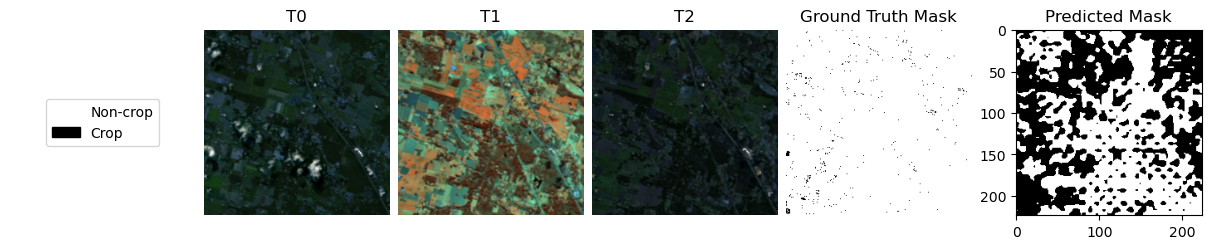

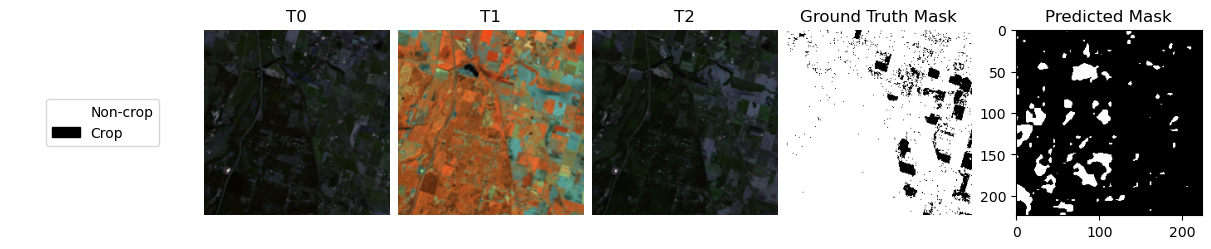

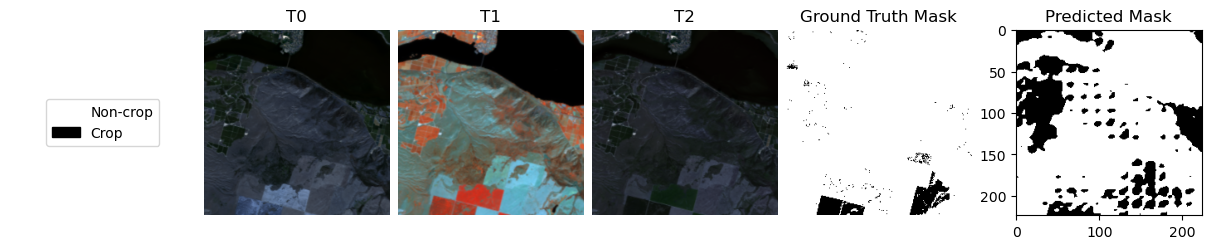

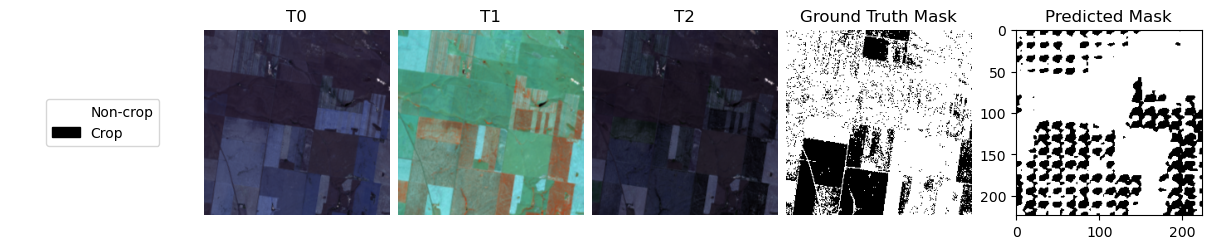

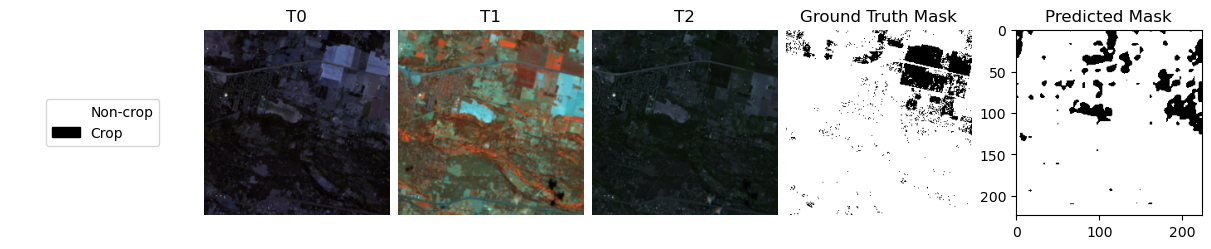

In [24]:
# now we can use the model for predictions and ploting!
best_ckpt_path = 'checkpoints/epoch-epoch=49-v3.ckpt'
model = SemanticSegmentationTask.load_from_checkpoint(
    best_ckpt_path,
    model_args=model.hparams.model_args,
    model_factory=model.hparams.model_factory
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_loader = data_module.test_dataloader()
model.to(device)
with torch.no_grad():
    batch = next(iter(test_loader))
    images = batch["image"].to(device)
    masks = batch["mask"].numpy()
    other_keys = batch.keys() - {"image", "mask", "filename"}
    rest = {k: batch[k].to(device) for k in other_keys}

    outputs = model(images, **rest)
    preds = torch.argmax(outputs.output, dim=1).cpu().numpy()

for i in range(5):
    sample = {key: batch[key][i] for key in batch}
    sample["prediction"] = preds[i]
    test_dataset.plot(sample)